# EDA v2 — bám sát pipeline preprocess hiện tại

Notebook này **thay thế cách tổ chức** của `eda_ver1.ipynb` (vẫn giữ nguyên, không xoá, dùng để tham khảo).
Thay vì khám phá tự do rồi tự đề xuất cách xử lý mới, notebook này đi theo đúng mạch:

> **EDA phát hiện vấn đề → chỉ ra chính xác hàm/ngưỡng nào trong pipeline preprocess hiện có đã giải quyết vấn đề đó.**

Pipeline preprocess hiện tại (đã code xong, không sửa trong notebook này):

- `src/pipelines/processing/cleaning.py` — lọc outlier sinh lý, forward-fill imputation, fallback theo (Age, Gender).
- `src/pipelines/processing/feature_engineering.py` — moving window, delta lag, expanding stats, qSOFA, NEWS, EtCO2 mask.
- `src/pipelines/processing/feature_builder.py` — bọc feature_engineering.py, chọn cột feature cho model, dựng lookback.
- `src/pipelines/processing/preprocessor.py` — bọc cleaning.py, chọn log-transform theo skew, chuẩn hoá (z-score), tạo `FittedPreprocessor`.
- `src/pipelines/validation/quality_gate.py` — kiểm tra chất lượng silver layer.

Toàn bộ ngưỡng/tham số trong notebook (skew_threshold, impute_columns, moving_window_hours, delta_lag_hours, lookback_hours, positive_weight, physiological ranges, alias cột...) được **đọc trực tiếp từ config/module thật**, không hardcode lại, để notebook luôn khớp với preprocess ngay cả khi config đổi sau này.

Các vấn đề EDA phát hiện nhưng **preprocess hiện tại chưa xử lý** được gom riêng vào mục Phụ lục ở cuối, không trộn vào mạch chính.

Mỗi mục đều có biểu đồ minh hoạ thay vì chỉ in số — màu sắc dùng palette cố định (xanh dương = chỉ số chính,
xám = không nổi bật, xanh lá = đạt, đỏ = cần chú ý) để đọc nhất quán xuyên suốt notebook.


## 0. Setup — nạp config thật, hàm preprocess thật, và bảng màu dùng chung

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch


def _find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "configs" / "retraining.yaml").exists():
            return candidate
    raise FileNotFoundError("Không tìm thấy configs/retraining.yaml từ thư mục hiện tại trở lên.")


# Dò ngược thư mục cha tìm configs/retraining.yaml làm mốc PROJECT_ROOT — không dựa vào
# sự tồn tại của cleaning.py cạnh notebook nữa, vì file đó giờ nằm trong src/pipelines/processing/.
PROJECT_ROOT = _find_project_root(Path.cwd())
RAW_DIR = PROJECT_ROOT / "data" / "raw"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "retraining.yaml"
SCHEMA_PATH = PROJECT_ROOT / "configs" / "data_schema.json"

with open(CONFIG_PATH, "r", encoding="utf-8") as handle:
    CONFIG = yaml.safe_load(handle)
with open(SCHEMA_PATH, "r", encoding="utf-8") as handle:
    SCHEMA = json.load(handle)

# cleaning.py / feature_engineering.py giờ là module thật trong src/pipelines/processing/ —
# import chuẩn, không cần importlib hack theo đường dẫn file nữa.
from src.pipelines.processing import cleaning, feature_engineering, feature_builder, preprocessor

IMPUTE_COLUMNS = list(CONFIG["preprocessing"]["impute_columns"])
FEATURE_COLUMNS = list(CONFIG["features"]["columns"])
WINDOW_SIZE = int(CONFIG["features"]["moving_window_hours"])
DELTA_LAG_HOURS = int(CONFIG["features"]["delta_lag_hours"])
LOOKBACK_HOURS = int(CONFIG["features"]["lookback_hours"])
SKEW_THRESHOLD = float(CONFIG["preprocessing"]["skew_threshold"])
POSITIVE_WEIGHT = float(CONFIG["model"]["positive_weight"])
ALIASES = SCHEMA["aliases"]
PATIENT_ID_PATTERN = SCHEMA["patient_id_pattern"]
CLINICAL_COLUMNS = SCHEMA["clinical_columns"]
LABEL_COLUMN = SCHEMA["label_column"]

# --- Bảng màu dùng chung cho toàn bộ notebook (palette cố định, không đổi theo cell) ---
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE_SEQ = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#1c5cab", "#0d366b"]
STATUS = {"good": "#0ca30c", "warning": "#fab219", "serious": "#ec835a", "critical": "#d03b3b"}
INK = {"primary": "#0b0b0b", "secondary": "#52514e", "muted": "#898781", "grid": "#e1e0d9", "baseline": "#c3c2b7"}
SURFACE = "#fcfcfb"
BLUE_CMAP = LinearSegmentedColormap.from_list("blue_seq", BLUE_SEQ)

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": INK["baseline"],
    "axes.labelcolor": INK["secondary"],
    "text.color": INK["primary"],
    "xtick.color": INK["muted"],
    "ytick.color": INK["muted"],
    "grid.color": INK["grid"],
    "font.size": 10,
})


def style_ax(ax, grid_axis="x"):
    # Áp dụng lại đúng 1 lần cho mọi biểu đồ: bỏ khung thừa, gridline mảnh, trục còn lại ẩn.
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.spines["left"].set_visible(grid_axis != "x")
    ax.spines["bottom"].set_visible(grid_axis != "y")
    ax.grid(axis=grid_axis, color=INK["grid"], linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)


print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR:", RAW_DIR)
print("impute_columns:", IMPUTE_COLUMNS)
print("feature_columns (moving/delta/expanding):", FEATURE_COLUMNS)
print(f"moving_window_hours={WINDOW_SIZE} | delta_lag_hours={DELTA_LAG_HOURS} | lookback_hours={LOOKBACK_HOURS}")
print(f"skew_threshold={SKEW_THRESHOLD} | positive_weight={POSITIVE_WEIGHT}")
print("aliases:", ALIASES)


PROJECT_ROOT: D:\AI vietnam\AIO2026\module 3\Early-Sepsis-Prediction-from-ICU-Clinical-Data
RAW_DIR: D:\AI vietnam\AIO2026\module 3\Early-Sepsis-Prediction-from-ICU-Clinical-Data\data\raw
impute_columns: ['HR', 'O2Sat', 'Temp']
feature_columns (moving/delta/expanding): ['HR', 'O2Sat', 'Temp', 'SBP', 'Resp']
moving_window_hours=6 | delta_lag_hours=1 | lookback_hours=5
skew_threshold=1.0 | positive_weight=40.0
aliases: {'TEM': 'Temp', 'SpO2': 'O2Sat'}


## 1. Manifest bệnh nhân & kiểm tra định danh

Dữ liệu vừa được thêm nằm ở `data/raw/training_setA/training/*.psv` và `data/raw/training_setB/training_setB/*.psv`
(lồng thư mục theo Set A/B, không phẳng). `data/raw/README.md` mô tả cấu trúc phẳng và một script
`scripts.bootstrap_splits` **không tồn tại** trong repo — đây là tài liệu bị lệch thực tế, không phải lỗi của dữ liệu.

Notebook này (giống `eda_ver1.ipynb` và `data-pipeline.ipynb`) dùng `rglob("*.psv")` nên tự động tìm được file
dù có lồng thư mục — dữ liệu **dùng được ngay** cho phân tích bên dưới mà không cần sắp xếp lại thư mục.

→ Kiểm tra định danh bên dưới đối chiếu đúng quy tắc trong `build_silver` (`silver_pipeline.py`):
regex `^p[0-9]{6}$` và phát hiện trùng ID giữa các file.


Tổng số file .psv tìm thấy (đệ quy, chịu được cấu trúc lồng Set A/B hiện tại): 40,336
Số ID không đúng định dạng '^p[0-9]{6}$': 0
Số ID trùng lặp giữa các file: 0


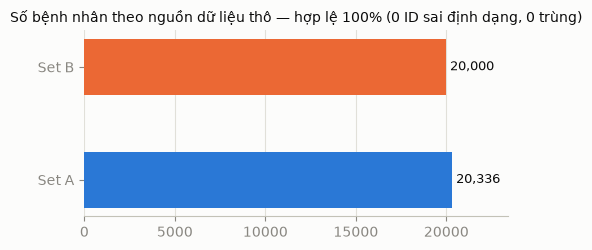

In [2]:
psv_files = sorted(RAW_DIR.rglob("*.psv"))
if not psv_files:
    raise FileNotFoundError(
        "Không tìm thấy file .psv trong data/raw. Hãy đặt dữ liệu PhysioNet vào data/raw truoc khi chạy notebook này."
    )

manifest = pd.DataFrame({"file_path": psv_files})
manifest["patient_id"] = manifest["file_path"].map(lambda p: p.stem)
manifest["valid_id_format"] = manifest["patient_id"].str.fullmatch(PATIENT_ID_PATTERN).astype(bool)
manifest["source"] = manifest["file_path"].map(
    lambda p: "Set A" if "training_setA" in str(p) else ("Set B" if "training_setB" in str(p) else "khác")
)

n_invalid_id = int((~manifest["valid_id_format"]).sum())
n_duplicate_id = int(manifest["patient_id"].duplicated().sum())

print(f"Tổng số file .psv tìm thấy (đệ quy, chịu được cấu trúc lồng Set A/B hiện tại): {len(manifest):,}")
print(f"Số ID không đúng định dạng '{PATIENT_ID_PATTERN}': {n_invalid_id}")
print(f"Số ID trùng lặp giữa các file: {n_duplicate_id}")
assert n_invalid_id == 0 and n_duplicate_id == 0, "Dữ liệu có ID bất thường — cần xử lý trước khi dùng cho retraining."

source_counts = manifest["source"].value_counts()
fig, ax = plt.subplots(figsize=(5, 2.6))
bars = ax.barh(source_counts.index, source_counts.values, color=[CAT[0], CAT[1]][: len(source_counts)], height=0.5)
for bar, value in zip(bars, source_counts.values):
    ax.text(bar.get_width() + max(source_counts.values) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{value:,}", va="center", ha="left", color=INK["primary"], fontsize=9)
ax.set_title("Số bệnh nhân theo nguồn dữ liệu thô — hợp lệ 100% (0 ID sai định dạng, 0 trùng)", fontsize=10, color=INK["primary"])
ax.set_xlim(0, source_counts.max() * 1.15)
style_ax(ax, grid_axis="x")
plt.tight_layout()
plt.show()


In [3]:
RANDOM_STATE = 42
SAMPLE_N = min(4000, len(manifest))
sample_manifest = manifest.sample(n=SAMPLE_N, random_state=RANDOM_STATE).reset_index(drop=True)
print(
    f"-> Từ đây trở đi dùng mẫu ngẫu nhiên {SAMPLE_N:,}/{len(manifest):,} bệnh nhân để notebook chạy nhanh. "
    "Các hàm/ngưỡng đối chiếu không đổi theo kích thước mẫu; chạy full dataset chỉ cần bỏ giới hạn SAMPLE_N."
)


def read_patient(file_path: Path) -> pd.DataFrame:
    frame = pd.read_csv(file_path, sep="|")
    frame.insert(0, "patient_id", file_path.stem)
    return frame


raw_df = pd.concat((read_patient(p) for p in sample_manifest["file_path"]), ignore_index=True)
print(f"Mẫu: {raw_df['patient_id'].nunique():,} bệnh nhân, {len(raw_df):,} dòng, {raw_df.shape[1]} cột")
raw_df.head()


-> Từ đây trở đi dùng mẫu ngẫu nhiên 4,000/40,336 bệnh nhân để notebook chạy nhanh. Các hàm/ngưỡng đối chiếu không đổi theo kích thước mẫu; chạy full dataset chỉ cần bỏ giới hạn SAMPLE_N.


Mẫu: 4,000 bệnh nhân, 152,908 dòng, 42 cột


,patient_id,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,p101214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,76.0,1,NaN,NaN,-49.08,1,0
1,p101214,98.0,98.0,NaN,121.0,82.0,64.0,24.0,NaN,NaN,...,NaN,NaN,NaN,76.0,1,NaN,NaN,-49.08,2,0
2,p101214,103.0,96.0,NaN,116.0,84.0,59.0,28.0,NaN,NaN,...,NaN,NaN,NaN,76.0,1,NaN,NaN,-49.08,3,0
3,p101214,108.0,98.0,NaN,150.0,101.0,73.0,24.0,NaN,NaN,...,NaN,NaN,NaN,76.0,1,NaN,NaN,-49.08,4,0
4,p101214,109.0,98.0,36.8,120.0,78.0,62.0,24.0,NaN,NaN,...,NaN,NaN,NaN,76.0,1,NaN,NaN,-49.08,5,0


## 2. Chuẩn hoá tên cột (alias)

→ Xử lý bởi rename theo `configs/data_schema.json:aliases` trong `_read_patient` (`silver_pipeline.py`).


In [4]:
alias_cols_present = [c for c in ALIASES if c in raw_df.columns]
print("Cột tên cũ (TEM/SpO2) xuất hiện trong dữ liệu thô:", alias_cols_present or "(không có - file đã dùng tên chuẩn Temp/O2Sat)")

df = raw_df.rename(columns=ALIASES)
assert not (set(ALIASES) & set(df.columns)), "Rename tạo trùng cột — cần rà lại alias map."


Cột tên cũ (TEM/SpO2) xuất hiện trong dữ liệu thô: (không có - file đã dùng tên chuẩn Temp/O2Sat)


## 3. Bức tranh missing data

Preprocess hiện tại xử lý missing theo **2 nhóm khác nhau**, cần tách rõ:

- `impute_columns` (`HR`, `O2Sat`, `Temp`): forward-fill theo bệnh nhân + fallback theo (Age, Gender) — `forward_fill_impute` (`src/pipelines/processing/cleaning.py`).
- Mọi cột còn lại: **không forward-fill**, chỉ được fill bằng mean của tập train (fold) rồi chuẩn hoá — `remaining_missing_policy` trong `fit_preprocessor`/`transform_patients` (`preprocessor.py`).


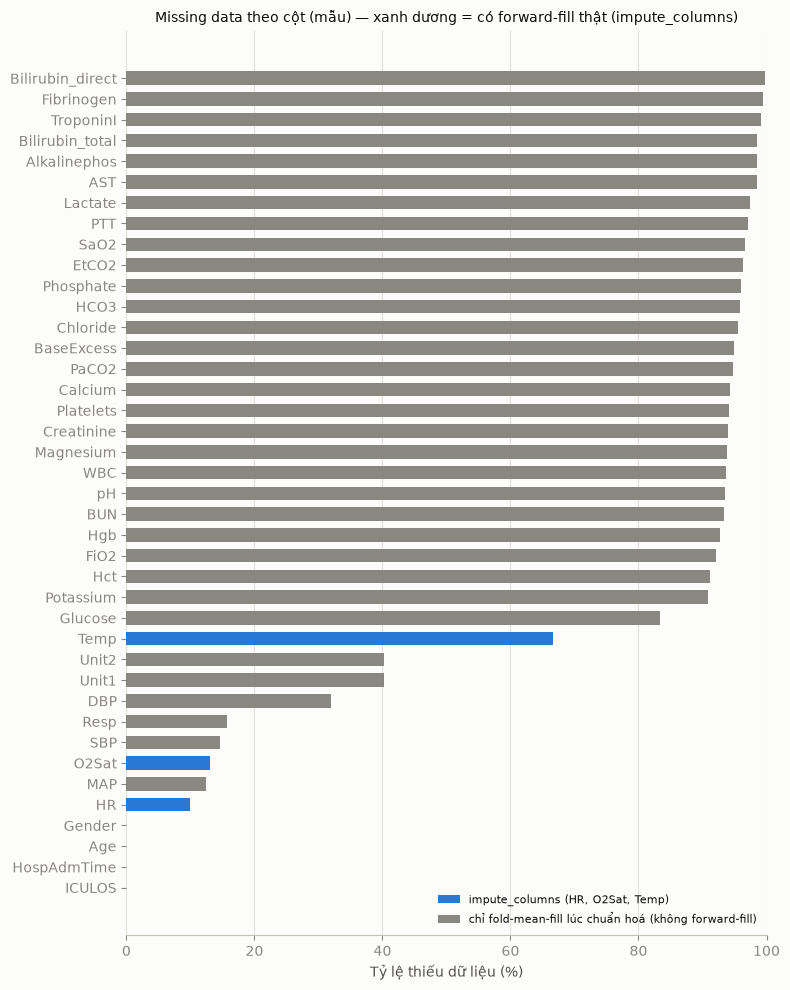

Nhóm impute_columns (%):
HR        9.9
O2Sat    13.1
Temp     66.7
dtype: float64


In [5]:
missing_rate = (df[CLINICAL_COLUMNS].isna().mean() * 100).sort_values(ascending=True)
colors = [CAT[0] if c in IMPUTE_COLUMNS else INK["muted"] for c in missing_rate.index]

fig, ax = plt.subplots(figsize=(8, 10))
bars = ax.barh(missing_rate.index, missing_rate.values, color=colors, height=0.65, zorder=3)
ax.set_xlabel("Tỷ lệ thiếu dữ liệu (%)")
ax.set_title("Missing data theo cột (mẫu) — xanh dương = có forward-fill thật (impute_columns)", fontsize=10)
ax.set_xlim(0, 100)
style_ax(ax, grid_axis="x")
legend_handles = [
    Patch(facecolor=CAT[0], label=f"impute_columns ({', '.join(IMPUTE_COLUMNS)})"),
    Patch(facecolor=INK["muted"], label="chỉ fold-mean-fill lúc chuẩn hoá (không forward-fill)"),
]
ax.legend(handles=legend_handles, loc="lower right", frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

print("Nhóm impute_columns (%):")
print(missing_rate.loc[missing_rate.index.isin(IMPUTE_COLUMNS)].round(1))


## 4. Outlier sinh lý (physiological range)

→ Xử lý bởi `filter_absolute_outliers` (`src/pipelines/processing/cleaning.py`), dùng `PHYSIOLOGICAL_RANGES` — import trực tiếp
từ module thật, không hardcode lại số trong notebook.

Lưu ý: `PHYSIOLOGICAL_RANGES` hiện chỉ định nghĩa cho `Temp`/`O2Sat`/`HR`. Các cột khác (SBP/DBP/MAP/Resp/26 lab)
**không có** range tuyệt đối trong preprocess hiện tại — chi tiết phát hiện liên quan xem ở Phụ lục cuối notebook.


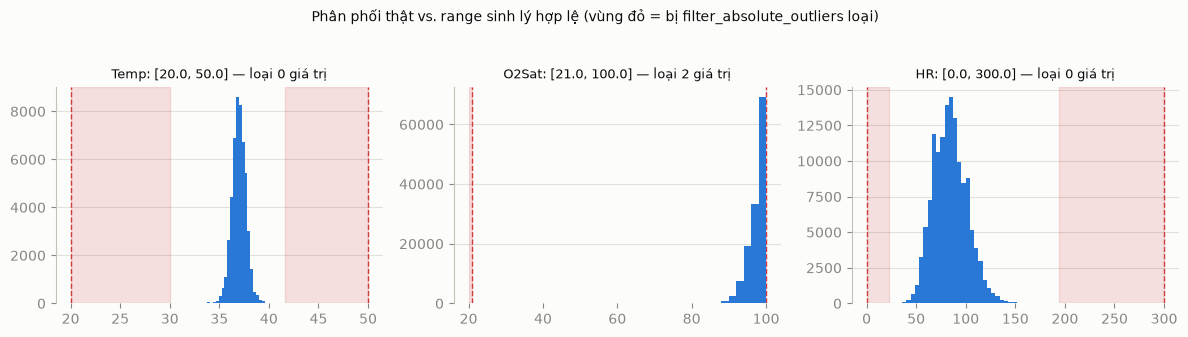

In [6]:
covered_columns = [c for c in ("Temp", "O2Sat", "HR") if c in df.columns]
before_na = df[covered_columns].isna().sum()
filtered_df = cleaning.filter_absolute_outliers(df)
after_na = filtered_df[covered_columns].isna().sum()
n_removed = (after_na - before_na).astype(int)

fig, axes = plt.subplots(1, len(covered_columns), figsize=(4 * len(covered_columns), 3.2))
for ax, column in zip(axes, covered_columns):
    lower, upper = cleaning.PHYSIOLOGICAL_RANGES[column]
    values = pd.to_numeric(df[column], errors="coerce").dropna()
    ax.hist(values, bins=40, color=CAT[0], zorder=3)
    ax.axvspan(values.min() if len(values) else lower, lower, color=STATUS["critical"], alpha=0.15, zorder=1)
    ax.axvspan(upper, values.max() if len(values) else upper, color=STATUS["critical"], alpha=0.15, zorder=1)
    ax.axvline(lower, color=STATUS["critical"], linewidth=1, linestyle="--")
    ax.axvline(upper, color=STATUS["critical"], linewidth=1, linestyle="--")
    ax.set_title(f"{column}: [{lower}, {upper}] — loại {int(n_removed[column])} giá trị", fontsize=9)
    style_ax(ax, grid_axis="y")
fig.suptitle("Phân phối thật vs. range sinh lý hợp lệ (vùng đỏ = bị filter_absolute_outliers loại)", fontsize=10, y=1.04)
plt.tight_layout()
plt.show()


## 5. Fallback theo (Age, Gender) khi không có gì để forward-fill

→ `fit_age_gender_normal_values` / `age_gender_normal_values` (`src/pipelines/processing/cleaning.py`) — dùng khi một bệnh nhân
không có giá trị HR/O2Sat/Temp nào trước một thời điểm để forward-fill lan truyền.


Số cặp (Age, Gender) fit được median từ mẫu: 1965


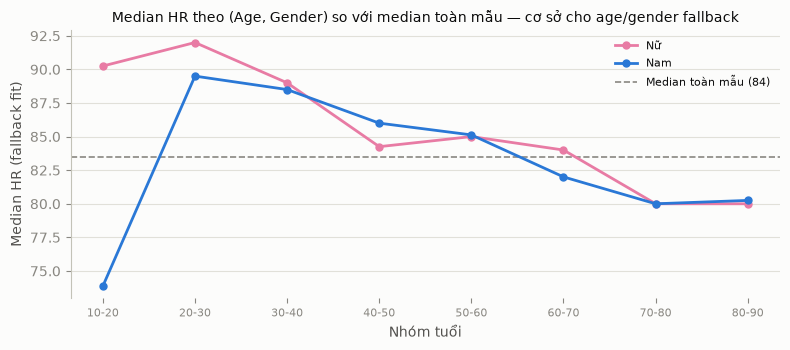

In [7]:
fitted_age_gender = cleaning.fit_age_gender_normal_values(
    filtered_df, columns=IMPUTE_COLUMNS, patient_col="patient_id"
)
print(f"Số cặp (Age, Gender) fit được median từ mẫu: {len(fitted_age_gender)}")

age_gender_rows = [
    {"Age": age, "Gender": "Nữ" if gender == 0 else "Nam", **values}
    for (age, gender), values in fitted_age_gender.items()
]
age_gender_df = pd.DataFrame(age_gender_rows)
age_bucket_edges = list(range(10, 101, 10))
age_gender_df["age_bucket"] = pd.cut(age_gender_df["Age"], bins=age_bucket_edges, right=False)
by_bucket = age_gender_df.groupby(["age_bucket", "Gender"], observed=True)["HR"].median().unstack("Gender")
global_median_hr = float(filtered_df["HR"].median())

fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(by_bucket.index))
if "Nữ" in by_bucket:
    ax.plot(x, by_bucket["Nữ"], marker="o", color=CAT[4], linewidth=2, markersize=5, label="Nữ", zorder=3)
if "Nam" in by_bucket:
    ax.plot(x, by_bucket["Nam"], marker="o", color=CAT[0], linewidth=2, markersize=5, label="Nam", zorder=3)
ax.axhline(global_median_hr, color=INK["muted"], linewidth=1.2, linestyle="--", label=f"Median toàn mẫu ({global_median_hr:.0f})")
ax.set_xticks(x)
ax.set_xticklabels([f"{int(iv.left)}-{int(iv.right)}" for iv in by_bucket.index], fontsize=8)
ax.set_xlabel("Nhóm tuổi")
ax.set_ylabel("Median HR (fallback fit)")
ax.set_title("Median HR theo (Age, Gender) so với median toàn mẫu — cơ sở cho age/gender fallback", fontsize=10)
ax.legend(frameon=False, fontsize=8, loc="upper right")
style_ax(ax, grid_axis="y")
plt.tight_layout()
plt.show()


## 6. Chạy thử imputation thật trên một bệnh nhân

→ `forward_fill_impute` (`src/pipelines/processing/cleaning.py`), dùng đúng `fitted_age_gender` vừa fit ở trên (mô phỏng cách
`fit_preprocessor` trong `preprocessor.py` gọi 2 hàm này nối tiếp nhau).


NaN còn lại sau forward-fill + age/gender fallback (kỳ vọng ~0 với bệnh nhân có Age/Gender hợp lệ):
HR       0
O2Sat    0
Temp     0
dtype: int64


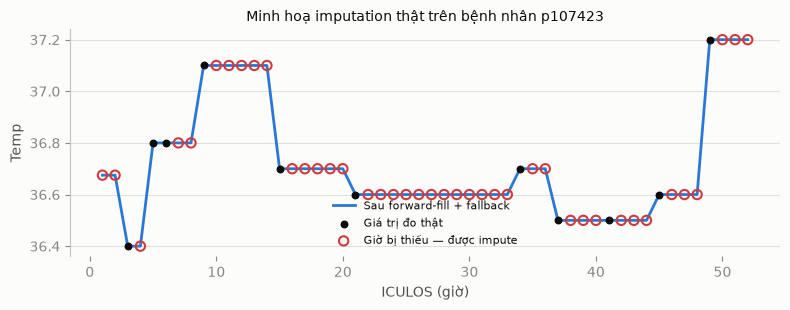

In [8]:
imputed_df = cleaning.forward_fill_impute(
    filtered_df,
    columns=IMPUTE_COLUMNS,
    patient_col="patient_id",
    fitted_age_gender_values=fitted_age_gender,
)
remaining_na = imputed_df[IMPUTE_COLUMNS].isna().sum()
print("NaN còn lại sau forward-fill + age/gender fallback (kỳ vọng ~0 với bệnh nhân có Age/Gender hợp lệ):")
print(remaining_na)


def longest_nan_run(series: pd.Series) -> int:
    is_na = series.isna().to_numpy()
    best = current = 0
    for flag in is_na:
        current = current + 1 if flag else 0
        best = max(best, current)
    return best


# Chọn 1 bệnh nhân có 1 khoảng gap Temp rõ ràng nhưng vừa phải (4-12 giờ liên tiếp),
# để hình minh hoạ đọc được (patient thiếu gần như toàn bộ sẽ toàn điểm đỏ, khó đọc).
run_lengths = filtered_df.groupby("patient_id")["Temp"].apply(longest_nan_run)
in_band = run_lengths[(run_lengths >= 4) & (run_lengths <= 12)]
example_patient_id = (in_band if len(in_band) else run_lengths).sort_values(ascending=False).index[0]

before = filtered_df.loc[filtered_df["patient_id"] == example_patient_id, ["ICULOS", "Temp"]].reset_index(drop=True)
after = imputed_df.loc[imputed_df["patient_id"] == example_patient_id, ["ICULOS", "Temp"]].reset_index(drop=True)
was_missing = before["Temp"].isna()

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(after["ICULOS"], after["Temp"], color=CAT[0], linewidth=2, label="Sau forward-fill + fallback", zorder=2)
ax.scatter(before.loc[~was_missing, "ICULOS"], before.loc[~was_missing, "Temp"],
           color=INK["primary"], s=22, zorder=3, label="Giá trị đo thật")
ax.scatter(after.loc[was_missing, "ICULOS"], after.loc[was_missing, "Temp"],
           facecolors="none", edgecolors=STATUS["critical"], s=45, linewidth=1.5, zorder=4,
           label="Giờ bị thiếu — được impute")
ax.set_xlabel("ICULOS (giờ)")
ax.set_ylabel("Temp")
ax.set_title(f"Minh hoạ imputation thật trên bệnh nhân {example_patient_id}", fontsize=10)
ax.legend(frameon=False, fontsize=8, loc="best")
style_ax(ax, grid_axis="y")
plt.tight_layout()
plt.show()


## 7. Tính toàn vẹn ICULOS & trùng bản ghi

→ Đối chiếu đúng 2 lớp kiểm tra hiện có: `build_silver` (`silver_pipeline.py`, raise lỗi cứng theo từng file)
và `validate_silver` (`quality_gate.py`, cảnh báo mềm trên toàn bộ frame).


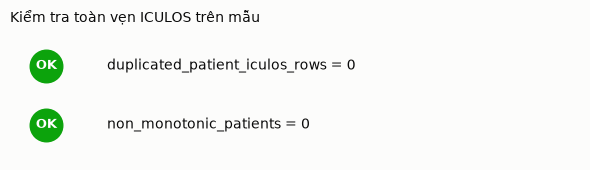

In [9]:
def check_iculos_integrity(frame: pd.DataFrame) -> dict:
    non_monotonic = 0
    for _, group in frame.groupby("patient_id", sort=False):
        if not group["ICULOS"].is_monotonic_increasing:
            non_monotonic += 1
    return {
        "non_monotonic_patients": non_monotonic,
        "duplicated_patient_iculos_rows": int(frame.duplicated(["patient_id", "ICULOS"]).sum()),
    }


integrity = check_iculos_integrity(imputed_df)

# 2 số liệu này là đếm pass/fail (kỳ vọng 0) — một bar chart ép hiển thị giá trị 0 sẽ
# tạo cột giả; dùng dạng "checklist trạng thái" (chấm màu + số liệu) rõ ràng hơn.
fig, ax = plt.subplots(figsize=(6, 1.8))
labels = list(integrity.keys())
values = list(integrity.values())
for row, (label, value) in enumerate(zip(labels, values)):
    color = STATUS["good"] if value == 0 else STATUS["critical"]
    mark = "OK" if value == 0 else "X"
    ax.scatter([0], [row], s=550, color=color, zorder=3)
    ax.text(0, row, mark, color="white", ha="center", va="center", fontsize=9, fontweight="bold", zorder=4)
    ax.text(0.25, row, f"{label} = {value}", va="center", fontsize=10, color=INK["primary"])
ax.set_xlim(-0.15, 2.2)
ax.set_ylim(-0.6, len(labels) - 0.4)
ax.axis("off")
ax.set_title("Kiểm tra toàn vẹn ICULOS trên mẫu", fontsize=10, loc="left")
plt.tight_layout()
plt.show()


## 8. Cảnh báo missingness cao (quality gate)

→ `validate_silver` (`quality_gate.py`) cảnh báo (không chặn) khi một cột có tỷ lệ NaN > 0.95.


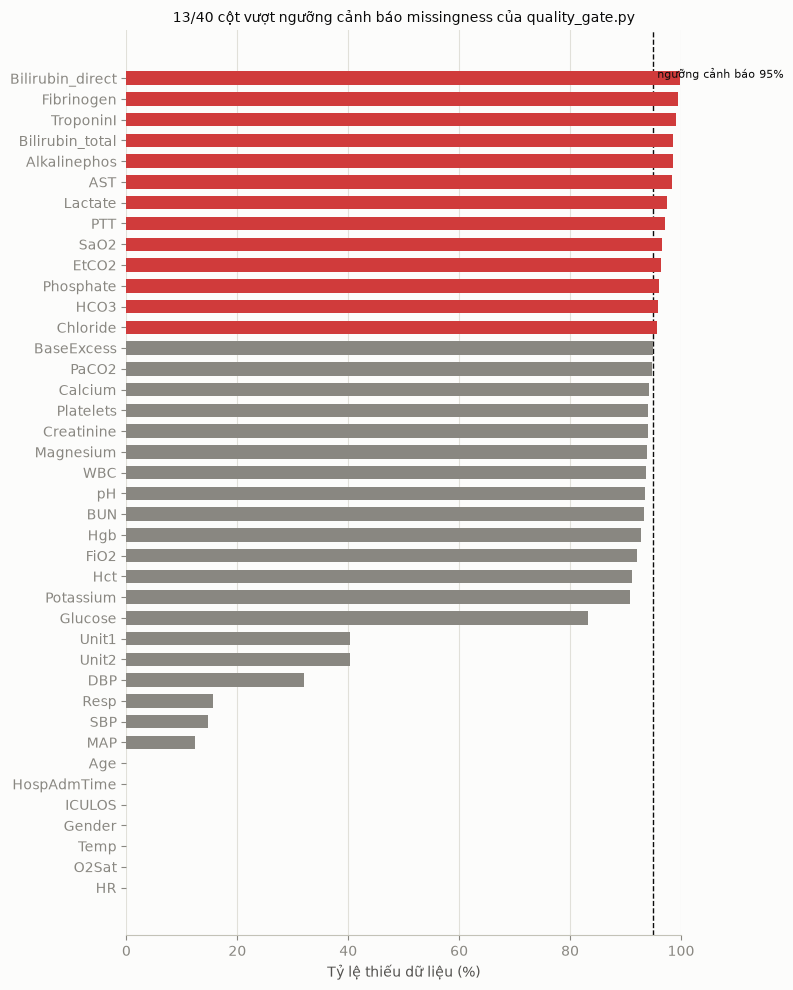

In [10]:
available_clinical_columns = [c for c in CLINICAL_COLUMNS if c in imputed_df.columns]
missing_full = (imputed_df[available_clinical_columns].isna().mean() * 100).sort_values(ascending=True)
colors = [STATUS["critical"] if v > 95 else INK["muted"] for v in missing_full.values]

fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(missing_full.index, missing_full.values, color=colors, height=0.65, zorder=3)
ax.axvline(95, color=INK["primary"], linewidth=1, linestyle="--")
ax.text(95, len(missing_full) - 0.5, " ngưỡng cảnh báo 95%", color=INK["primary"], fontsize=8, va="top")
ax.set_xlabel("Tỷ lệ thiếu dữ liệu (%)")
ax.set_xlim(0, 100)
ax.set_title(f"{int((missing_full > 95).sum())}/{len(missing_full)} cột vượt ngưỡng cảnh báo missingness của quality_gate.py", fontsize=10)
style_ax(ax, grid_axis="x")
plt.tight_layout()
plt.show()


## 9. Feature engineering — chạy đúng hàm production

→ Gọi trực tiếp `engineer_patient_features` (`src/pipelines/processing/feature_builder.py`), hàm này bọc
`add_all_feature_engineering` trong `src/pipelines/processing/feature_engineering.py` với tham số lấy từ `configs/retraining.yaml`
(`moving_window_hours`, `delta_lag_hours`, cột trong `features.columns`) — đúng 100% những gì Airflow DAG
và inference `team_v1` đang chạy.


Số cột mới sinh ra bởi engineer_patient_features: 43


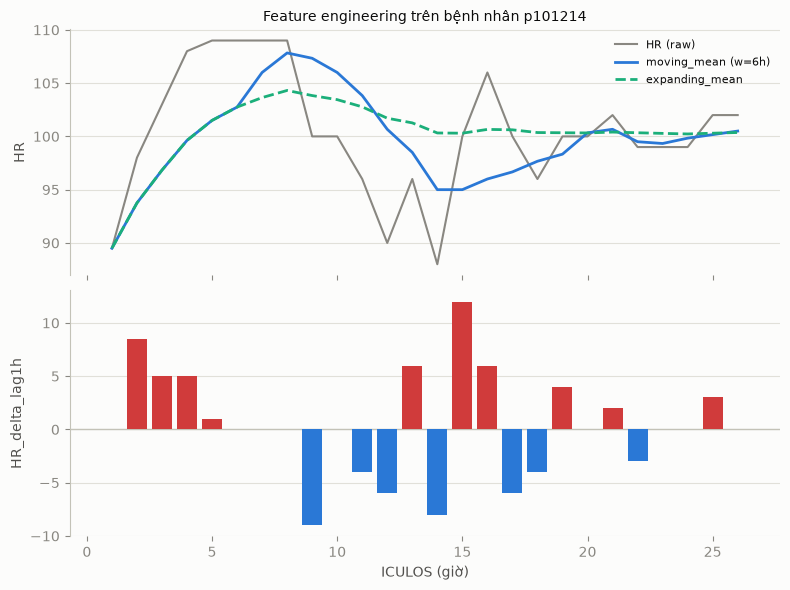

Toàn bộ cột mới: ['HR_moving_mean_w6', 'HR_moving_var_w6', 'HR_moving_slope_w6', 'O2Sat_moving_mean_w6', 'O2Sat_moving_var_w6', 'O2Sat_moving_slope_w6', 'Temp_moving_mean_w6', 'Temp_moving_var_w6', 'Temp_moving_slope_w6', 'SBP_moving_mean_w6', 'SBP_moving_var_w6', 'SBP_moving_slope_w6', 'Resp_moving_mean_w6', 'Resp_moving_var_w6', 'Resp_moving_slope_w6', 'HR_delta_lag1h', 'O2Sat_delta_lag1h', 'Temp_delta_lag1h', 'SBP_delta_lag1h', 'Resp_delta_lag1h', 'partial_qSOFA', 'NEWS_resp', 'NEWS_o2sat', 'NEWS_sbp', 'NEWS_hr', 'NEWS_temp', 'NEWS', 'HR_expanding_mean', 'HR_expanding_min', 'HR_expanding_max', 'O2Sat_expanding_mean', 'O2Sat_expanding_min', 'O2Sat_expanding_max', 'Temp_expanding_mean', 'Temp_expanding_min', 'Temp_expanding_max', 'SBP_expanding_mean', 'SBP_expanding_min', 'SBP_expanding_max', 'Resp_expanding_mean', 'Resp_expanding_min', 'Resp_expanding_max', 'EtCO2_mask']


In [11]:
demo_patients = imputed_df["patient_id"].unique()[:15]
demo_df = imputed_df[imputed_df["patient_id"].isin(demo_patients)].copy()

engineered_df = feature_builder.engineer_patient_features(demo_df, CONFIG)
new_columns = [c for c in engineered_df.columns if c not in demo_df.columns]
print(f"Số cột mới sinh ra bởi engineer_patient_features: {len(new_columns)}")

one_patient = engineered_df[engineered_df["patient_id"] == demo_patients[0]].reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axes[0].plot(one_patient["ICULOS"], one_patient["HR"], color=INK["muted"], linewidth=1.5, label="HR (raw)", zorder=2)
axes[0].plot(one_patient["ICULOS"], one_patient["HR_moving_mean_w6"], color=CAT[0], linewidth=2, label=f"moving_mean (w={WINDOW_SIZE}h)", zorder=3)
axes[0].plot(one_patient["ICULOS"], one_patient["HR_expanding_mean"], color=CAT[2], linewidth=2, linestyle="--", label="expanding_mean", zorder=3)
axes[0].set_ylabel("HR")
axes[0].set_title(f"Feature engineering trên bệnh nhân {demo_patients[0]}", fontsize=10)
axes[0].legend(frameon=False, fontsize=8, loc="best")
style_ax(axes[0], grid_axis="y")

axes[1].bar(one_patient["ICULOS"], one_patient["HR_delta_lag1h"],
            color=[STATUS["critical"] if v > 0 else CAT[0] for v in one_patient["HR_delta_lag1h"]],
            width=0.8, zorder=3)
axes[1].axhline(0, color=INK["baseline"], linewidth=1)
axes[1].set_ylabel(f"HR_delta_lag{DELTA_LAG_HOURS}h")
axes[1].set_xlabel("ICULOS (giờ)")
style_ax(axes[1], grid_axis="y")
plt.tight_layout()
plt.show()

print("Toàn bộ cột mới:", new_columns)


## 10. Chọn cột feature cho model & log-transform theo skew

→ `model_feature_columns` (`feature_builder.py`) loại bỏ đúng `patient_id`/`source`/`SepsisLabel`/`batch_id`/`dataset_split`.
→ Ngưỡng log-transform lấy động từ `configs/retraining.yaml: preprocessing.skew_threshold`, cùng công thức
`abs(skew) > skew_threshold` mà `_select_log_columns` (`preprocessor.py`) dùng.


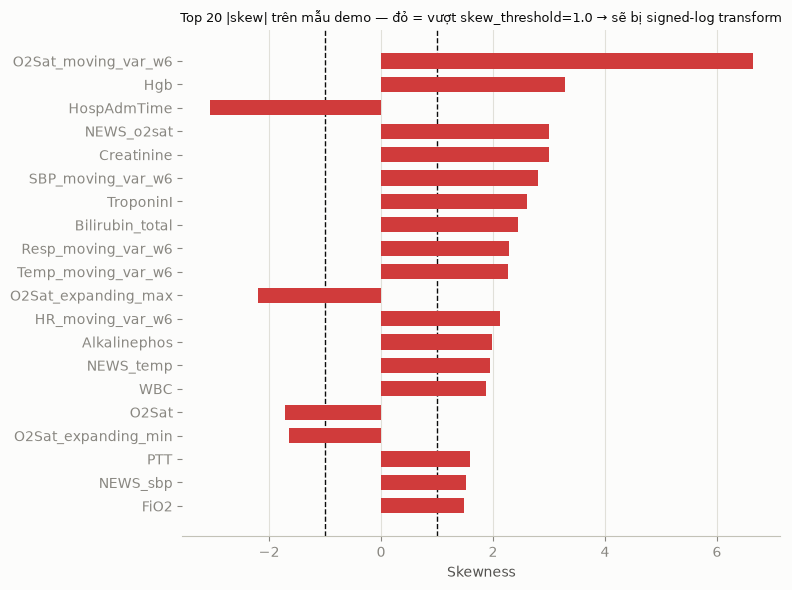

Số cột feature cho model: 83
Số cột sẽ được signed-log transform trên mẫu demo: 32/83


In [12]:
feature_columns_for_model = feature_builder.model_feature_columns(engineered_df, SCHEMA)
skews = engineered_df[feature_columns_for_model].apply(lambda s: pd.to_numeric(s, errors="coerce").skew()).dropna()
top_skew = skews.reindex(skews.abs().sort_values(ascending=True).index).tail(20)
colors = [STATUS["critical"] if abs(v) > SKEW_THRESHOLD else INK["muted"] for v in top_skew.values]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_skew.index, top_skew.values, color=colors, height=0.65, zorder=3)
ax.axvline(SKEW_THRESHOLD, color=INK["primary"], linewidth=1, linestyle="--")
ax.axvline(-SKEW_THRESHOLD, color=INK["primary"], linewidth=1, linestyle="--")
ax.set_xlabel("Skewness")
ax.set_title(f"Top 20 |skew| trên mẫu demo — đỏ = vượt skew_threshold={SKEW_THRESHOLD} → sẽ bị signed-log transform", fontsize=9.5)
style_ax(ax, grid_axis="x")
plt.tight_layout()
plt.show()

log_columns = skews[skews.abs() > SKEW_THRESHOLD].index.tolist()
print(f"Số cột feature cho model: {len(feature_columns_for_model)}")
print(f"Số cột sẽ được signed-log transform trên mẫu demo: {len(log_columns)}/{len(feature_columns_for_model)}")


## 11. Chạy thẳng qua `fit_preprocessor` / `transform_patients` thật (production, đầu-cuối)

→ Đây là bước "chốt": gọi thẳng 2 hàm mà Airflow DAG retraining và inference `team_v1` đang dùng, trên chính
dữ liệu vừa thêm, để xác nhận toàn bộ chuỗi (clean → feature engineer → log-transform → chuẩn hoá) chạy được
không lỗi trên dữ liệu thật — không chỉ từng bước rời rạc như các mục trên.


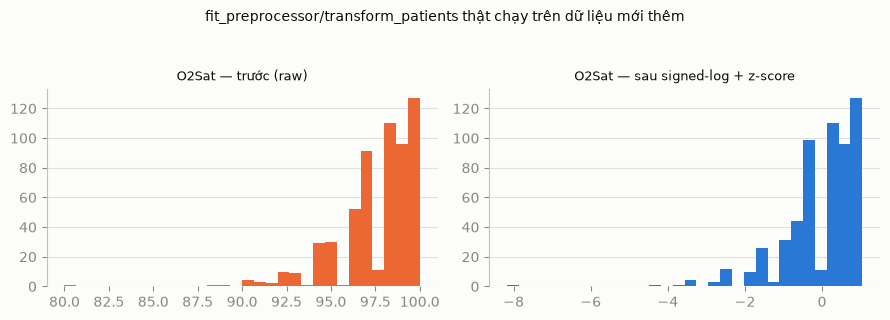

FittedPreprocessor: 83 feature columns, 32 log columns
transform_patients: NaN còn lại sau chuẩn hoá = 0


In [13]:
fitted = preprocessor.fit_preprocessor(demo_df, CONFIG, SCHEMA)
transformed_df = preprocessor.transform_patients(demo_df, fitted, CONFIG)
n_remaining_na = int(transformed_df[fitted.feature_columns].isna().sum().sum())

example_log_col = next((c for c in fitted.log_columns if c in engineered_df.columns), None)

if example_log_col is not None:
    fig, axes = plt.subplots(1, 2, figsize=(9, 3))
    raw_values = pd.to_numeric(engineered_df[example_log_col], errors="coerce").dropna()
    transformed_values = pd.to_numeric(transformed_df[example_log_col], errors="coerce").dropna()
    axes[0].hist(raw_values, bins=30, color=CAT[1], zorder=3)
    axes[0].set_title(f"{example_log_col} — trước (raw)", fontsize=9)
    style_ax(axes[0], grid_axis="y")
    axes[1].hist(transformed_values, bins=30, color=CAT[0], zorder=3)
    axes[1].set_title(f"{example_log_col} — sau signed-log + z-score", fontsize=9)
    style_ax(axes[1], grid_axis="y")
    fig.suptitle("fit_preprocessor/transform_patients thật chạy trên dữ liệu mới thêm", fontsize=10, y=1.05)
    plt.tight_layout()
    plt.show()

print(f"FittedPreprocessor: {len(fitted.feature_columns)} feature columns, {len(fitted.log_columns)} log columns")
print(f"transform_patients: NaN còn lại sau chuẩn hoá = {n_remaining_na}")


## 12. Snapshot mất cân bằng lớp (chỉ nêu số liệu)

→ Chỉ đối chiếu số liệu thật với `model.positive_weight` đang cấu hình — **không đề xuất đổi** trong notebook này
(nằm ngoài phạm vi sửa EDA); phát hiện liên quan (nếu số liệu lệch nhiều) được ghi lại ở Phụ lục.


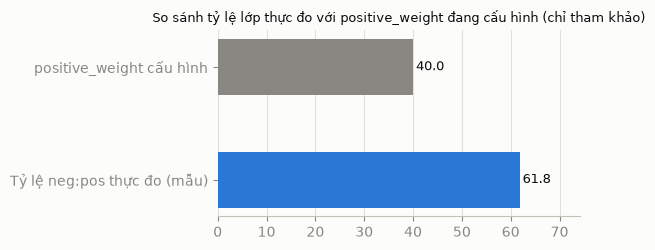

neg=150,474, pos=2,434, neg:pos = 61.8:1 (row-level, trên mẫu)


In [14]:
label_series = imputed_df[LABEL_COLUMN]
n_neg, n_pos = int((label_series == 0).sum()), int((label_series == 1).sum())
ratio_actual = n_neg / n_pos if n_pos else float("nan")

fig, ax = plt.subplots(figsize=(6, 2.6))
bars = ax.barh(["Tỷ lệ neg:pos thực đo (mẫu)", "positive_weight cấu hình"], [ratio_actual, POSITIVE_WEIGHT],
               color=[CAT[0], INK["muted"]], height=0.5, zorder=3)
for bar, value in zip(bars, [ratio_actual, POSITIVE_WEIGHT]):
    ax.text(bar.get_width() + max(ratio_actual, POSITIVE_WEIGHT) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{value:.1f}", va="center", color=INK["primary"], fontsize=9)
ax.set_xlim(0, max(ratio_actual, POSITIVE_WEIGHT) * 1.2)
ax.set_title("So sánh tỷ lệ lớp thực đo với positive_weight đang cấu hình (chỉ tham khảo)", fontsize=9.5)
style_ax(ax, grid_axis="x")
plt.tight_layout()
plt.show()

print(f"neg={n_neg:,}, pos={n_pos:,}, neg:pos = {ratio_actual:.1f}:1 (row-level, trên mẫu)")


## 13. Độ phủ lookback window (chỉ nêu số liệu)

→ Đối chiếu `features.lookback_hours` (config) với thời điểm xuất hiện nhãn dương đầu tiên của từng bệnh nhân sepsis
trong mẫu. Đây là input thật cho `add_lookback` (`feature_builder.py`) — chỉ nêu số liệu, không đổi `lookback_hours`
trong notebook này.


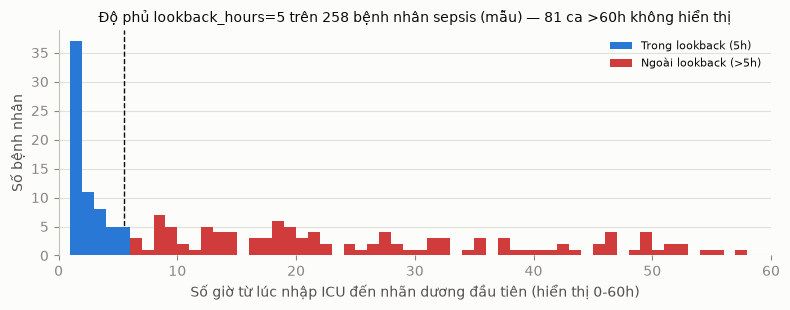

Tỷ lệ có nhãn dương đầu tiên trong 5 giờ đầu ICU: 25.6%


In [15]:
def first_positive_offset(group: pd.DataFrame):
    positive_hours = group.loc[group[LABEL_COLUMN] == 1, "ICULOS"]
    if positive_hours.empty:
        return np.nan
    return positive_hours.min() - group["ICULOS"].min() + 1


onset_offsets = (
    imputed_df.groupby("patient_id")[["ICULOS", LABEL_COLUMN]]
    .apply(first_positive_offset, include_groups=False)
    .dropna()
)
within_lookback = float((onset_offsets <= LOOKBACK_HOURS).mean()) if len(onset_offsets) else float("nan")

# Đuôi dài (vài ca sepsis rất muộn) sẽ dẹt hết vùng đáng xem gần lookback_hours nếu
# vẽ hết trục x — giới hạn hiển thị 0-60h và báo riêng số ca ngoài phạm vi này.
DISPLAY_CAP = 60
max_hour = int(onset_offsets.max()) if len(onset_offsets) else LOOKBACK_HOURS
bins = np.arange(1, min(max_hour, DISPLAY_CAP) + 3)
covered = onset_offsets[onset_offsets <= LOOKBACK_HOURS]
uncovered = onset_offsets[(onset_offsets > LOOKBACK_HOURS) & (onset_offsets <= DISPLAY_CAP)]
n_beyond_cap = int((onset_offsets > DISPLAY_CAP).sum())

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(covered, bins=bins, color=CAT[0], zorder=3, label=f"Trong lookback ({LOOKBACK_HOURS}h)")
ax.hist(uncovered, bins=bins, color=STATUS["critical"], zorder=3, label=f"Ngoài lookback (>{LOOKBACK_HOURS}h)")
ax.axvline(LOOKBACK_HOURS + 0.5, color=INK["primary"], linewidth=1, linestyle="--")
ax.set_xlim(0, DISPLAY_CAP)
ax.set_xlabel(f"Số giờ từ lúc nhập ICU đến nhãn dương đầu tiên (hiển thị 0-{DISPLAY_CAP}h)")
ax.set_ylabel("Số bệnh nhân")
title = f"Độ phủ lookback_hours={LOOKBACK_HOURS} trên {len(onset_offsets)} bệnh nhân sepsis (mẫu)"
if n_beyond_cap:
    title += f" — {n_beyond_cap} ca >{DISPLAY_CAP}h không hiển thị"
ax.set_title(title, fontsize=10)
ax.legend(frameon=False, fontsize=8, loc="upper right")
style_ax(ax, grid_axis="y")
plt.tight_layout()
plt.show()

print(f"Tỷ lệ có nhãn dương đầu tiên trong {LOOKBACK_HOURS} giờ đầu ICU: {within_lookback:.1%}")


## 14. Tổng kết đối chiếu EDA ↔ Preprocess

| Vấn đề EDA phát hiện (mục) | Hàm / file xử lý | Ngưỡng chính xác |
|---|---|---|
| Tên cột không nhất quán (mục 2) | `_read_patient` rename — `silver_pipeline.py` | `configs/data_schema.json: aliases` |
| Thiếu dữ liệu (mục 3) | `forward_fill_impute` (3 cột) + fold-mean-fill (cột còn lại) | `impute_columns` (config) / `remaining_missing_policy` (`preprocessor.py`) |
| Outlier sinh lý (mục 4) | `filter_absolute_outliers` — `src/pipelines/processing/cleaning.py` | `PHYSIOLOGICAL_RANGES`: Temp∈[20,50], O2Sat∈[21,100], HR∈[0,300] |
| Thiếu giá trị đầu chuỗi (mục 5-6) | `fit_age_gender_normal_values`/`age_gender_normal_values` — `src/pipelines/processing/cleaning.py` | median theo (Age, Gender) từ train, fallback HR=75/Temp=37/O2Sat=98 |
| ICULOS không đơn điệu / trùng bản ghi (mục 7) | `build_silver` (hard fail) + `validate_silver` (soft warning) | — |
| Missingness cao bất thường (mục 8) | `validate_silver` — `quality_gate.py` | > 0.95 → warning |
| Cần tín hiệu xu hướng/tốc độ thay đổi/điểm lâm sàng (mục 9) | `engineer_patient_features` → `add_all_feature_engineering` | window=`moving_window_hours`, lag=`delta_lag_hours` (config) |
| Loại cột không phải feature (mục 10) | `model_feature_columns` — `feature_builder.py` | loại `patient_id`/`source`/`SepsisLabel`/`batch_id`/`dataset_split` |
| Phân phối lệch (mục 10) | `_select_log_columns`/`_signed_log` — `preprocessor.py` | `abs(skew) > skew_threshold` (config) |
| Toàn bộ chuỗi clean→feature→transform (mục 11) | `fit_preprocessor`/`transform_patients` — `preprocessor.py` | chạy được đầu-cuối trên dữ liệu mới, không lỗi |

Mọi phát hiện chính trong notebook này đều có nơi xử lý cụ thể, đang chạy thật trong pipeline hiện tại — không có
đề xuất xử lý mới nào bị bỏ ngỏ trong mạch chính.


## 15. Vì sao mỗi phát hiện dẫn tới đúng bước xử lý đó (phân tích nguyên nhân)

Mục 14 chỉ nói **cái gì** xử lý vấn đề nào. Mục này giải thích **tại sao** — số liệu bên dưới lấy trực tiếp
từ các biến đã tính ở các mục trên (không hardcode), nên luôn khớp với lần chạy notebook hiện tại.


In [16]:
from IPython.display import Markdown, display

worst_labs = missing_rate.sort_values(ascending=False).head(3)
impute_missing = missing_rate.loc[IMPUTE_COLUMNS].sort_values()
hr_range = float(by_bucket.stack().max() - by_bucket.stack().min())
engineered_in_top_skew = sum(
    1 for c in top_skew.index if any(tag in c for tag in ("_moving_", "_expanding_", "_delta_"))
)
n_beyond_cap_txt = f"{n_beyond_cap} ca" if n_beyond_cap else "0 ca"

analysis = f'''
**1. Missing data ({', '.join(f'{c}={v:.1f}%' for c, v in impute_missing.items())}) so với nhóm lab
({', '.join(f'{c}={v:.1f}%' for c, v in worst_labs.items())}) → vì sao chỉ 3 cột được forward-fill.**
`HR/O2Sat/Temp` là sinh hiệu đo liên tục bằng monitor, khoảng trống thường ngắn nên forward-fill (lấy giá trị
gần nhất) hợp lý về sinh lý. Lab như trên chỉ được đo khi bác sĩ chỉ định — {worst_labs.iloc[0]:.1f}% thời gian
không có giá trị; forward-fill một cột thiếu gần hết sẽ "bịa" hàng chục giờ dữ liệu giả từ 1 lần đo. Đây là lý do
`remaining_missing_policy=fold_train_mean_then_zero` tồn tại như chính sách **riêng** cho nhóm lab, và vì sao
`features.columns` trong `engineer_patient_features` chỉ giới hạn đúng 5 cột đủ đầy — tính rolling variance trên
cột thiếu gần hết chỉ ra NaN, vô nghĩa.

**2. Outlier sinh lý (loại {int(n_removed.sum())} giá trị trên mẫu) → vì sao lọc phải chạy TRƯỚC impute.**
Forward-fill lan truyền giá trị về phía trước theo thời gian. Một giá trị rác (lỗi cảm biến) nếu không bị lọc
trước sẽ bị chép lại (ffill) sang các giờ sau cho tới lần đo thật kế tiếp — biến 1 lỗi đo thành hàng chục giờ sai.
`filter_absolute_outliers` vì vậy luôn đứng đầu chuỗi xử lý trong `fit_preprocessor`, không thể đảo thứ tự.

**3. Median HR dao động ~{hr_range:.0f} bpm giữa các nhóm (Age, Gender) → vì sao không dùng median toàn cục.**
Forward-fill không giúp được gì cho những giờ đầu tiên (chưa có phép đo nào trước đó). Nếu dùng 1 median chung
cho mọi bệnh nhân mới nhập viện, một bệnh nhân có baseline lệch theo tuổi/giới sẽ bị gán sai giá trị "bình
thường" ngay từ đầu — đúng lúc mô hình cần nhạy nhất (nhãn sepsis được dịch sớm 6h). Đây là lý do
`fit_age_gender_normal_values` tồn tại thay vì một hằng số đơn giản.

**4. Kiểm tra ICULOS đạt 0 vi phạm → vì sao check này phải đứng TRƯỚC feature engineering.**
Mọi phép tính ở bước sau (`moving_mean`, `delta_lag{DELTA_LAG_HOURS}h`, `expanding_mean`, `add_lookback`) giả
định thứ tự thời gian đúng và không trùng lặp. ICULOS bị đảo hoặc trùng sẽ khiến `rolling`/`diff` tính trên các
giờ sai vị trí — hỏng toàn bộ tín hiệu xu hướng mà không có lỗi runtime nào báo hiệu. Đây là lý do check này là
hard-fail ở `build_silver`, không phải chỉ warning.

**5. {engineered_in_top_skew}/20 cột lệch nhất (top |skew|) là cột VỪA ĐƯỢC SINH RA bởi feature engineering,
không phải cột thô → vì sao log-transform chạy SAU feature engineering.**
Phương sai/độ dốc trong cửa sổ trượt tự nhiên lệch mạnh: phần lớn thời gian bệnh nhân ổn định (giá trị ~0),
thỉnh thoảng dao động mạnh (giá trị rất lớn) → phân phối dài đuôi. `_select_log_columns` vì vậy phải chạy trên
toàn bộ `model_feature_columns` (gồm cả cột sinh ra) sau `engineer_patient_features`, không log-transform dữ
liệu thô rồi mới tính feature.

**6. Tỷ lệ lớp thực đo {ratio_actual:.1f}:1 (so với `positive_weight={POSITIVE_WEIGHT:.0f}` cấu hình) →
vì sao cần custom objective thay vì logloss thường.**
Với tỷ lệ dương hiếm cỡ này, logloss thường bị nhóm âm áp đảo — mô hình đạt loss thấp chỉ bằng cách luôn dự
đoán "không sepsis". Đây là lý do tồn tại `weighted_logloss` (`positive_weight` trong `training/objectives.py`):
trọng số dương phải đủ lớn để một lần bỏ sót sepsis "đắt" hơn nhiều so với một cảnh báo giả — đúng tinh thần utility
score của Challenge (phạt trễ nặng hơn phạt false positive).

**7. {within_lookback:.1%} bệnh nhân sepsis có nhãn dương trong {LOOKBACK_HOURS}h đầu ICU ({n_beyond_cap_txt}
onset rất muộn, không hiển thị trên biểu đồ) → vì sao `add_lookback` dùng padding=0.0 thay vì loại bỏ bệnh nhân.**
Nhóm dương vốn đã cực hiếm (mục 6). Loại thêm các ca thiếu đủ {LOOKBACK_HOURS}h lịch sử sẽ làm mất cân bằng
nghiêm trọng hơn. Vì vậy `add_lookback` giữ lại toàn bộ bệnh nhân, đệm phần lịch sử thiếu bằng 0.0 — đánh đổi
bằng việc model phải tự học "0 ở block lag xa" có thể là "không có dữ liệu", không phải "giá trị đo được là 0".

**Kết nối tổng thể**: mỗi bước sau kế thừa một giả định mà bước trước phải đảm bảo —
`alias → outlier filter → impute (ffill + age/gender fallback) → check ICULOS → feature engineering (5 cột đủ
đầy) → chọn log columns (trên cả feature sinh ra) → chuẩn hoá (mean/std theo fold) → lookback (pad 0.0)`.
Đảo 2 bước liền kề bất kỳ sẽ phá giả định của bước sau (vd. chuẩn hoá trước khi impute sẽ làm mean/std bị lệch
bởi chính các NaN chưa xử lý) — đây là lý do thứ tự này cố định trong `fit_preprocessor`/`transform_patients`.
'''

display(Markdown(analysis))



**1. Missing data (HR=9.9%, O2Sat=13.1%, Temp=66.7%) so với nhóm lab
(Bilirubin_direct=99.8%, Fibrinogen=99.4%, TroponinI=99.1%) → vì sao chỉ 3 cột được forward-fill.**
`HR/O2Sat/Temp` là sinh hiệu đo liên tục bằng monitor, khoảng trống thường ngắn nên forward-fill (lấy giá trị
gần nhất) hợp lý về sinh lý. Lab như trên chỉ được đo khi bác sĩ chỉ định — 99.8% thời gian
không có giá trị; forward-fill một cột thiếu gần hết sẽ "bịa" hàng chục giờ dữ liệu giả từ 1 lần đo. Đây là lý do
`remaining_missing_policy=fold_train_mean_then_zero` tồn tại như chính sách **riêng** cho nhóm lab, và vì sao
`features.columns` trong `engineer_patient_features` chỉ giới hạn đúng 5 cột đủ đầy — tính rolling variance trên
cột thiếu gần hết chỉ ra NaN, vô nghĩa.

**2. Outlier sinh lý (loại 2 giá trị trên mẫu) → vì sao lọc phải chạy TRƯỚC impute.**
Forward-fill lan truyền giá trị về phía trước theo thời gian. Một giá trị rác (lỗi cảm biến) nếu không bị lọc
trước sẽ bị chép lại (ffill) sang các giờ sau cho tới lần đo thật kế tiếp — biến 1 lỗi đo thành hàng chục giờ sai.
`filter_absolute_outliers` vì vậy luôn đứng đầu chuỗi xử lý trong `fit_preprocessor`, không thể đảo thứ tự.

**3. Median HR dao động ~18 bpm giữa các nhóm (Age, Gender) → vì sao không dùng median toàn cục.**
Forward-fill không giúp được gì cho những giờ đầu tiên (chưa có phép đo nào trước đó). Nếu dùng 1 median chung
cho mọi bệnh nhân mới nhập viện, một bệnh nhân có baseline lệch theo tuổi/giới sẽ bị gán sai giá trị "bình
thường" ngay từ đầu — đúng lúc mô hình cần nhạy nhất (nhãn sepsis được dịch sớm 6h). Đây là lý do
`fit_age_gender_normal_values` tồn tại thay vì một hằng số đơn giản.

**4. Kiểm tra ICULOS đạt 0 vi phạm → vì sao check này phải đứng TRƯỚC feature engineering.**
Mọi phép tính ở bước sau (`moving_mean`, `delta_lag1h`, `expanding_mean`, `add_lookback`) giả
định thứ tự thời gian đúng và không trùng lặp. ICULOS bị đảo hoặc trùng sẽ khiến `rolling`/`diff` tính trên các
giờ sai vị trí — hỏng toàn bộ tín hiệu xu hướng mà không có lỗi runtime nào báo hiệu. Đây là lý do check này là
hard-fail ở `build_silver`, không phải chỉ warning.

**5. 7/20 cột lệch nhất (top |skew|) là cột VỪA ĐƯỢC SINH RA bởi feature engineering,
không phải cột thô → vì sao log-transform chạy SAU feature engineering.**
Phương sai/độ dốc trong cửa sổ trượt tự nhiên lệch mạnh: phần lớn thời gian bệnh nhân ổn định (giá trị ~0),
thỉnh thoảng dao động mạnh (giá trị rất lớn) → phân phối dài đuôi. `_select_log_columns` vì vậy phải chạy trên
toàn bộ `model_feature_columns` (gồm cả cột sinh ra) sau `engineer_patient_features`, không log-transform dữ
liệu thô rồi mới tính feature.

**6. Tỷ lệ lớp thực đo 61.8:1 (so với `positive_weight=40` cấu hình) →
vì sao cần custom objective thay vì logloss thường.**
Với tỷ lệ dương hiếm cỡ này, logloss thường bị nhóm âm áp đảo — mô hình đạt loss thấp chỉ bằng cách luôn dự
đoán "không sepsis". Đây là lý do tồn tại `weighted_logloss` (`positive_weight` trong `training/objectives.py`):
trọng số dương phải đủ lớn để một lần bỏ sót sepsis "đắt" hơn nhiều so với một cảnh báo giả — đúng tinh thần utility
score của Challenge (phạt trễ nặng hơn phạt false positive).

**7. 25.6% bệnh nhân sepsis có nhãn dương trong 5h đầu ICU (81 ca
onset rất muộn, không hiển thị trên biểu đồ) → vì sao `add_lookback` dùng padding=0.0 thay vì loại bỏ bệnh nhân.**
Nhóm dương vốn đã cực hiếm (mục 6). Loại thêm các ca thiếu đủ 5h lịch sử sẽ làm mất cân bằng
nghiêm trọng hơn. Vì vậy `add_lookback` giữ lại toàn bộ bệnh nhân, đệm phần lịch sử thiếu bằng 0.0 — đánh đổi
bằng việc model phải tự học "0 ở block lag xa" có thể là "không có dữ liệu", không phải "giá trị đo được là 0".

**Kết nối tổng thể**: mỗi bước sau kế thừa một giả định mà bước trước phải đảm bảo —
`alias → outlier filter → impute (ffill + age/gender fallback) → check ICULOS → feature engineering (5 cột đủ
đầy) → chọn log columns (trên cả feature sinh ra) → chuẩn hoá (mean/std theo fold) → lookback (pad 0.0)`.
Đảo 2 bước liền kề bất kỳ sẽ phá giả định của bước sau (vd. chuẩn hoá trước khi impute sẽ làm mean/std bị lệch
bởi chính các NaN chưa xử lý) — đây là lý do thứ tự này cố định trong `fit_preprocessor`/`transform_patients`.


## Phụ lục — Vấn đề chưa được preprocess hiện tại xử lý

Các phát hiện dưới đây **không nằm trong phạm vi preprocess hiện tại** (không có hàm/ngưỡng nào xử lý), giữ lại
để tham khảo nhưng **không** đưa vào mạch chính ở trên. Xem thêm mục "Hướng phát triển tiếp theo" trong
[`REPORT.md`](../docs/REPORT.md) và [`docs/PRODUCTION_STRUCTURE_PROPOSAL.md`](../docs/PRODUCTION_STRUCTURE_PROPOSAL.md).

1. **Physiological range chỉ phủ 3 cột** (Temp/O2Sat/HR) — SBP/DBP/MAP/Resp và 26 cột lab không có range tuyệt đối nào
   trong `cleaning.py` (`src/pipelines/processing/cleaning.py`). `eda_ver1.ipynb` (mục "Distributions & Outliers") còn phát hiện `FiO2` gần như 100% giá trị
   nằm ngoài range đề xuất — khả năng dữ liệu lưu dạng phân số (0-1) thay vì phần trăm, cần rà lại đơn vị trước khi
   thêm range cho cột này.
2. **`forward_fill_impute` không giới hạn độ dài gap** — với bệnh nhân có gap dài (nhiều giờ liền không đo), giá trị
   forward-fill có thể không còn phản ánh đúng tình trạng hiện tại.
3. **Chỉ có 1 mask feature** (`EtCO2_mask`) trong khi nhiều lab missing rất nhiều nhưng vẫn có tương quan với
   `SepsisLabel` (theo `eda_ver1.ipynb` mục "Validating impute/mask assumptions") — chưa có mask tương ứng.
4. **`model.positive_weight = 40.0` (config) so với tỷ lệ lớp thực tế đo được ở mục 12** — nếu số liệu đo được
   trên dữ liệu đầy đủ lệch nhiều so với 40:1, đây là điểm cần cân nhắc khi retrain thật, không tự sửa trong EDA.
5. **`features.lookback_hours = 5` (config) so với độ phủ đo được ở mục 13** — nếu tỷ lệ bệnh nhân có nhãn dương
   trong 5 giờ đầu đáng kể, lookback window hiện tại có thể không đủ lịch sử cho nhóm này.

Không có mục nào ở trên được sửa trong preprocess (`src/pipelines/processing/cleaning.py`,
`src/pipelines/processing/feature_engineering.py`,
`src/pipelines/processing/*`) như một phần của việc tái cấu trúc EDA lần này.
